In [14]:
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import shutil

print("Tensorflow version: " + tf.__version__)
print("Keras version: " + keras.__version__)

Tensorflow version: 2.19.0
Keras version: 3.13.2


In [15]:
########################################################################################################################
# SETUP AND CREATE OUTPUT FOLDER
########################################################################################################################

out_folder = os.path.join(os.getcwd(), 'mnist_cnn')
if os.path.exists(out_folder):
    shutil.rmtree(out_folder)
os.mkdir(out_folder)

In [16]:
########################################################################################################################
# LOADING DATA
########################################################################################################################

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

x_train = x_train / 255.0
x_test = x_test / 255.0

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [17]:
########################################################################################################################
# BUILDING MODEL
########################################################################################################################

model = keras.models.Sequential([
    keras.layers.InputLayer((28, 28)),
    keras.layers.Reshape((28, 28, 1)),
    keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    keras.layers.MaxPool2D((2, 2)),
    keras.layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    keras.layers.Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'),
    keras.layers.MaxPool2D((2, 2)),
    keras.layers.GlobalAvgPool2D(),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,410 (1.49 MB)

 Trainable params: 390,410 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
########################################################################################################################
# TRAINING MODEL
########################################################################################################################

early_stopping = keras.callbacks.EarlyStopping(monitor='val_sparse_categorical_accuracy', mode='max',
                                               patience=30, restore_best_weights=True, verbose=1)

reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_sparse_categorical_accuracy', mode='max',
                                              factor=0.1, patience=10, verbose=1)

csv_logger = keras.callbacks.CSVLogger(os.path.join(out_folder, 'training.csv'))

hist = model.fit(x_train, y_train, batch_size=32, epochs=1000,
                 validation_data=(x_test, y_test), verbose=2,
                 callbacks=[early_stopping, reduce_lr, csv_logger])

path = os.path.join(out_folder, 'trained_model.keras')
model.save(path, include_optimizer=False)

Epoch 1/1000
1875/1875 - 17s - 9ms/step - loss: 0.8710 - sparse_categorical_accuracy: 0.7292 - val_loss: 0.3025 - val_sparse_categorical_accuracy: 0.9177 - learning_rate: 1.0000e-04
Epoch 2/1000
1875/1875 - 15s - 8ms/step - loss: 0.2848 - sparse_categorical_accuracy: 0.9187 - val_loss: 0.2677 - val_sparse_categorical_accuracy: 0.9194 - learning_rate: 1.0000e-04
Epoch 3/1000
1875/1875 - 12s - 7ms/step - loss: 0.2055 - sparse_categorical_accuracy: 0.9406 - val_loss: 0.1901 - val_sparse_categorical_accuracy: 0.9420 - learning_rate: 1.0000e-04
Epoch 4/1000
1875/1875 - 12s - 6ms/step - loss: 0.1667 - sparse_categorical_accuracy: 0.9505 - val_loss: 0.1299 - val_sparse_categorical_accuracy: 0.9612 - learning_rate: 1.0000e-04
Epoch 5/1000
1875/1875 - 12s - 6ms/step - loss: 0.1423 - sparse_categorical_accuracy: 0.9576 - val_loss: 0.1070 - val_sparse_categorical_accuracy: 0.9679 - learning_rate: 1.0000e-04
Epoch 6/1000
1875/1875 - 12s - 7ms/step - loss: 0.1230 - sparse_categorical_accuracy: 0.96

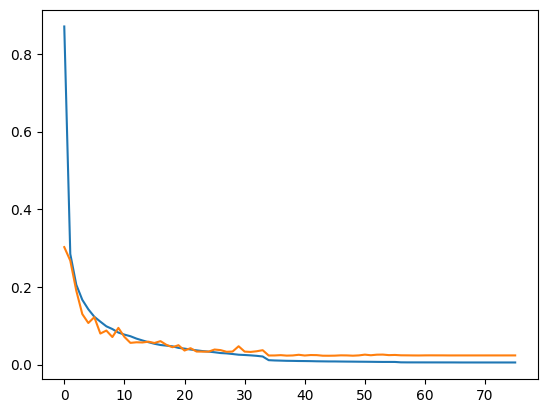

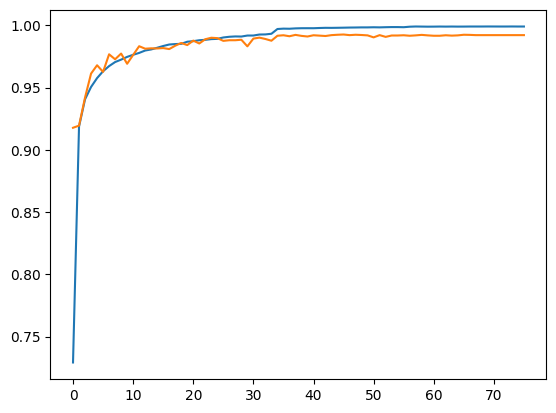

In [19]:
########################################################################################################################
# VIEW TRAINING GRAPHS
########################################################################################################################

plt.clf()
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.savefig(os.path.join(out_folder, 'training_loss.png'))
plt.show()

plt.clf()
plt.plot(hist.history['sparse_categorical_accuracy'])
plt.plot(hist.history['val_sparse_categorical_accuracy'])
plt.savefig(os.path.join(out_folder, 'training_accuracy.png'))
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0229 - sparse_categorical_accuracy: 0.9926
[0.0228576697409153, 0.9926000237464905]
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Pronađeno je ukupno 74 pogrešno klasifikovanih slika.


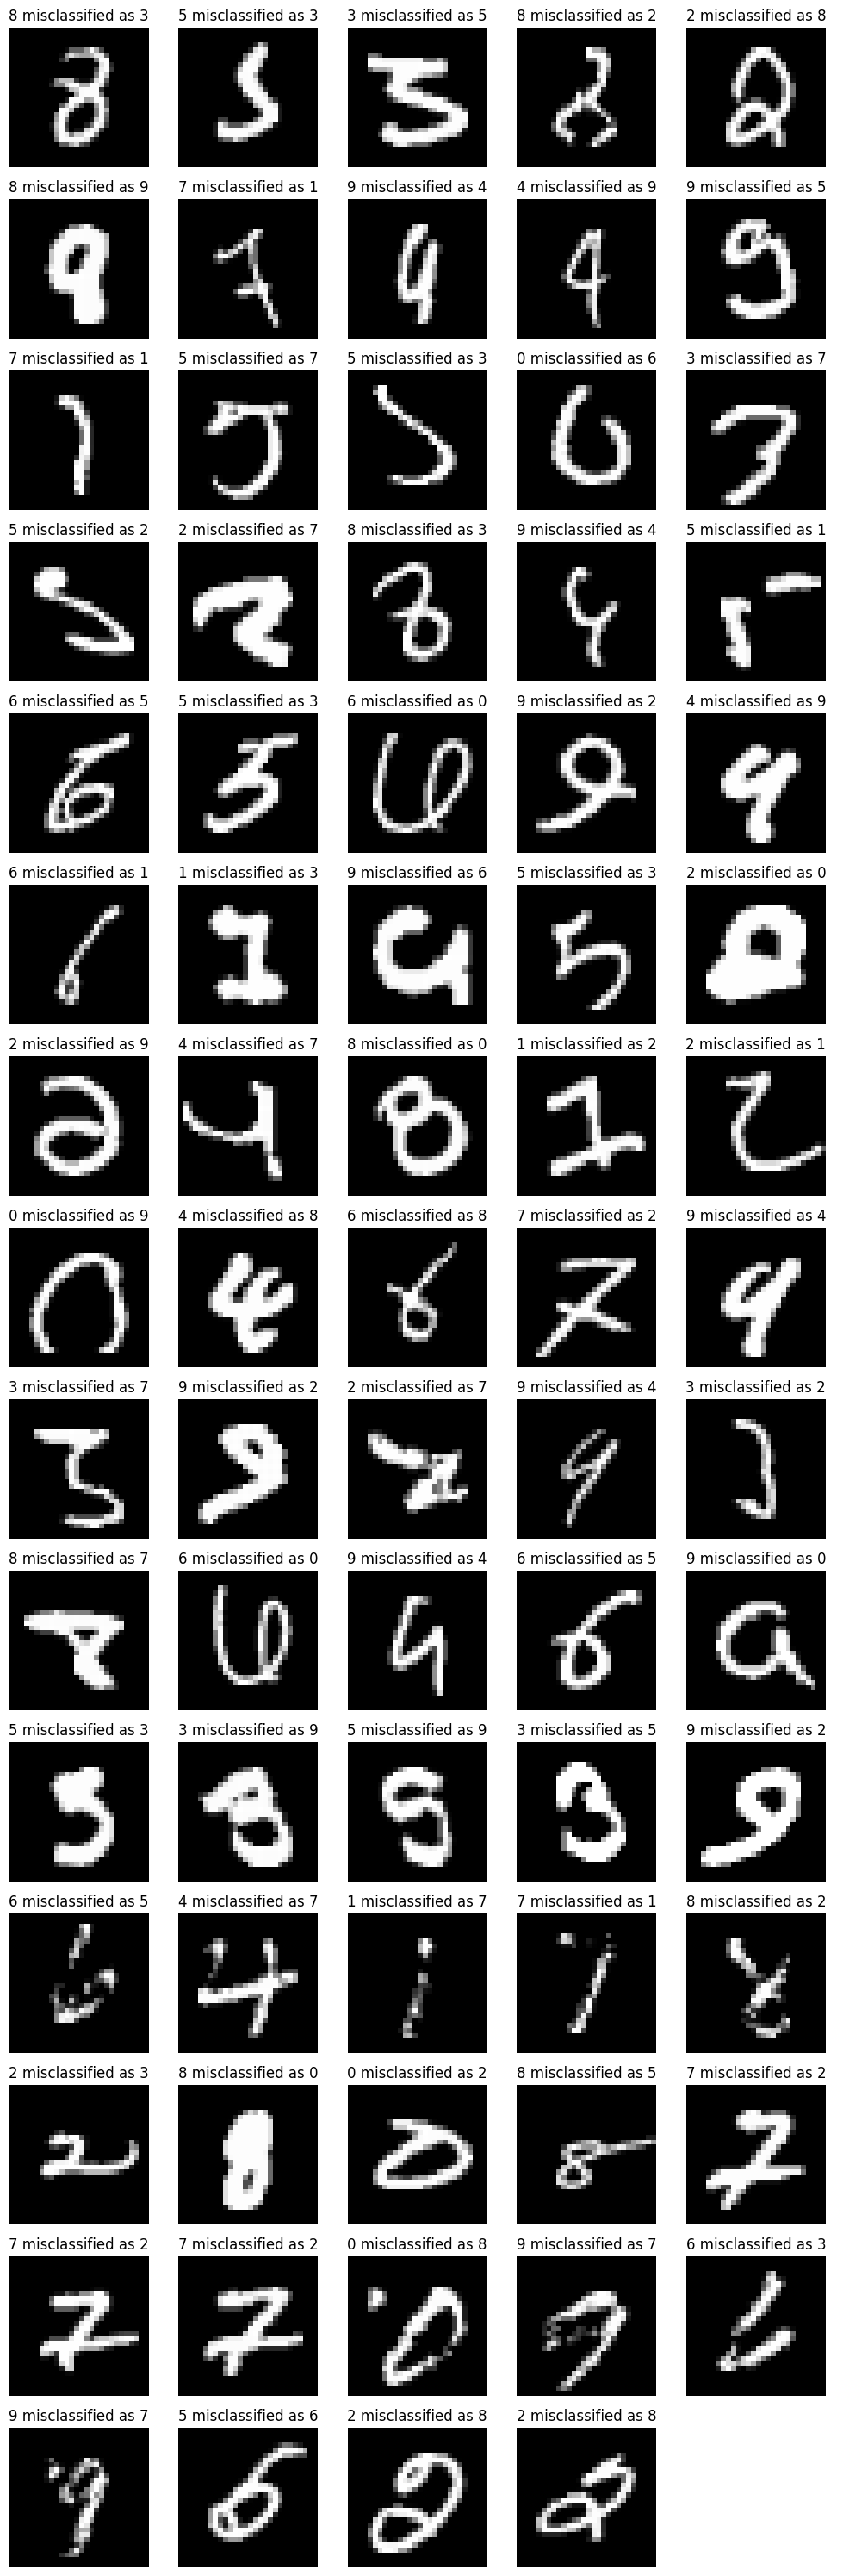

In [20]:
########################################################################################################################
# EVALUATE MODEL
########################################################################################################################

res = model.evaluate(x_test, y_test, batch_size=32)
print(res)

y_out = model.predict(x_test, batch_size=32)
y_out = np.argmax(y_out, axis=1)

# Pronalaženje svih indeksa gde je model pogrešio
error_indices = np.where(y_out != y_test)[0]
total_errors = len(error_indices)

print(f"Pronađeno je ukupno {total_errors} pogrešno klasifikovanih slika.")

if total_errors > 0:
    # Dinamičko određivanje dimenzija grida
    cols = 5  # Fiksiramo broj kolona radi preglednosti
    rows = math.ceil(total_errors / cols)  # Zaokruživanje na gore za broj redova

    # Visinu figure (figsize) takođe pravimo dinamičkom kako se slike ne bi sabile
    fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))
    axes = axes.flatten() # Ravnanje niza osa za laku iteraciju kroz 1D niz

    # Iteracija samo kroz indekse sa greškama
    for i, idx in enumerate(error_indices):
        img = x_test[idx]
        out = y_out[idx]
        exp = y_test[idx]

        title = f'{exp} misclassified as {out}'

        # Čuvanje slike u folder (na disku)
        file_path = os.path.join(out_folder, f'{i+1} ({title}).png')
        plt.imsave(file_path, img.squeeze(), cmap='gray')

        # Popunjavanje grida
        ax = axes[i]
        ax.imshow(img.squeeze(), cmap='gray')
        ax.set_title(title)
        ax.axis('off')

    # Uklanjanje viška praznih osa (ako ukupan broj grešaka nije deljiv sa 5)
    for j in range(total_errors, rows * cols):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Model je savršeno klasifikovao sve slike (0 grešaka).")